<a href="https://colab.research.google.com/github/19mddill/Machine_Learning_Notebooks/blob/main/ensemble_learning_and_random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import make_moons
from sklearn.ensemble import RandomForestClassifier,VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

In [ ]:
X,y = make_moons(n_samples=500,noise=0.3,random_state=42)
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42)

In [ ]:
voting_clf = VotingClassifier(
    estimators=[
        ('lr',LogisticRegression()),
        ('rf',RandomForestClassifier()),
        ('svc',SVC())
    ]
)

In [ ]:
voting_clf.fit(X_train,y_train)

VotingClassifier(estimators=[('lr', LogisticRegression()),
                             ('rf', RandomForestClassifier()), ('svc', SVC())])

In [ ]:
for name,clf in voting_clf.named_estimators_.items():
    print(name,"=",clf.score(X_test,y_test))

lr = 0.864
rf = 0.896
svc = 0.896


In [ ]:
voting_clf.predict(X_test[:1])

array([1])

In [ ]:
[clf.predict(X_test[:1]) for clf in voting_clf.estimators_]

[array([1]), array([1]), array([0])]

In [ ]:
voting_clf.score(X_test,y_test)

0.904

In [ ]:
voting_clf.voting = 'soft'
voting_clf.named_estimators["svc"].probability = True
voting_clf.fit(X_train,y_train)


VotingClassifier(estimators=[('lr', LogisticRegression()),
                             ('rf', RandomForestClassifier()),
                             ('svc', SVC(probability=True))],
                 voting='soft')

In [ ]:
for name,clf in voting_clf.named_estimators_.items():
    print(name,"=",clf.score(X_test,y_test))

lr = 0.864
rf = 0.896
svc = 0.896


In [ ]:
print("\n=== Probabilities for X_test[0] ===")
print(f"True label: {y_test[0]}")
for name, clf in zip(voting_clf.named_estimators_, voting_clf.estimators_):
    proba = clf.predict_proba(X_test[:1])[0]
    print(f"{name}: class0={proba[0]:.3f}, class1={proba[1]:.3f}")


=== Probabilities for X_test[0] ===
True label: 1
lr: class0=0.499, class1=0.501
rf: class0=0.450, class1=0.550
svc: class0=0.577, class1=0.423


In [ ]:
X_test[:1]

array([[0.50169252, 0.21717211]])

In [ ]:
[clf.predict_proba(X_test[:1])[0]
                       for clf in voting_clf.estimators_]

[array([0.49900001, 0.50099999]),
 array([0.45, 0.55]),
 array([0.57737367, 0.42262633])]

In [ ]:
import numpy as np
np.array([clf.predict_proba(X_test[:1])[0]
                       for clf in voting_clf.estimators_])

array([[0.49900001, 0.50099999],
       [0.45      , 0.55      ],
       [0.57737367, 0.42262633]])

In [ ]:

print("\n=== Averaged Probabilities (soft voting logic) ===")
all_probas = np.array([clf.predict_proba(X_test[:1])[0]
                       for clf in voting_clf.estimators_])
avg_proba = all_probas.mean(axis=0)
print(f"class0 avg={avg_proba[0]:.3f}, class1 avg={avg_proba[1]:.3f}")
print(f"Soft vote picks: class {np.argmax(avg_proba)}")


=== Averaged Probabilities (soft voting logic) ===
class0 avg=0.509, class1 avg=0.491
Soft vote picks: class 0


In [ ]:
avg_proba

array([0.50879122, 0.49120878])

In [ ]:

print(f"\nEnsemble prediction: {voting_clf.predict(X_test[:1])[0]}")
print(f"Ensemble score: {voting_clf.score(X_test, y_test):.4f}")


Ensemble prediction: 0
Ensemble score: 0.9200


# Bagging

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

In [ ]:
X,y = make_moons(n_samples=500,noise=0.3,random_state=42)
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42)

In [ ]:
X_train.size

750

In [ ]:
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(),
    n_estimators=500,
    max_samples=100,
    bootstrap=True,
    n_jobs=-1,
    oob_score=True
)

In [ ]:
bag_clf.fit(X_train,y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), max_samples=100,
                  n_estimators=500, n_jobs=-1, oob_score=True)

In [ ]:
bag_clf.score(X_test,y_test)

0.92

In [ ]:
bag_clf.oob_score_

0.92

In [ ]:
from sklearn.metrics import accuracy_score
y_pred = bag_clf.predict(X_test)
accuracy_score(y_test,y_pred)

0.92

In [ ]:
bag_clf.oob_decision_function_[:3]

array([[0.30526316, 0.69473684],
       [0.41315789, 0.58684211],
       [1.        , 0.        ]])

# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rnd_clf = RandomForestClassifier(n_estimators=500,max_leaf_nodes=16,n_jobs=-1,random_state=42)

In [ ]:
rnd_clf.fit(X_train,y_train)

RandomForestClassifier(max_leaf_nodes=16, n_estimators=500, n_jobs=-1,
                       random_state=42)

In [ ]:
y_pred_rf = rnd_clf.predict(X_test)

In [ ]:
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(max_features="sqrt",max_leaf_nodes=16),
    n_estimators=500,
    n_jobs = -1,
    random_state=42
)

In [ ]:
from sklearn.datasets import load_iris
iris = load_iris(as_frame = True)


In [ ]:
rnd_clf = RandomForestClassifier(n_estimators=500,n_jobs=-1,random_state=42)
rnd_clf.fit(iris["data"],iris["target"])

RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=42)

In [ ]:
for score, name in zip(rnd_clf.feature_importances_,iris.data.columns):
  print(round(score,2),name)

0.11 sepal length (cm)
0.02 sepal width (cm)
0.44 petal length (cm)
0.42 petal width (cm)


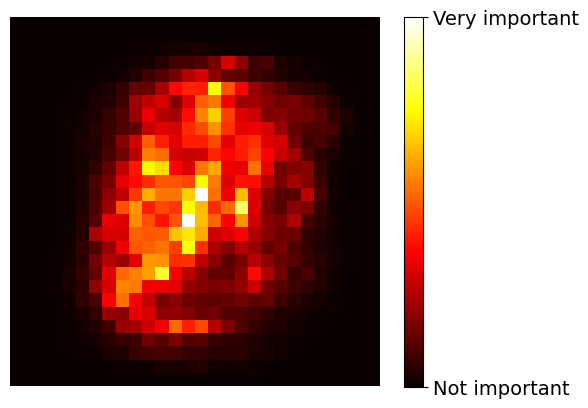

In [ ]:
from matplotlib import pyplot as plt

from sklearn.datasets import fetch_openml

X_mnist, y_mnist = fetch_openml('mnist_784', return_X_y=True, as_frame=False,
                                parser='auto')

rnd_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rnd_clf.fit(X_mnist, y_mnist)

heatmap_image = rnd_clf.feature_importances_.reshape(28, 28)
plt.imshow(heatmap_image, cmap="hot")
cbar = plt.colorbar(ticks=[rnd_clf.feature_importances_.min(),
                           rnd_clf.feature_importances_.max()])
cbar.ax.set_yticklabels(['Not important', 'Very important'], fontsize=14)
plt.axis("off")
plt.show()

# Ada Boosting

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

In [ ]:
ada_clf = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1), n_estimators = 30,
    learning_rate= 0.5, random_state=42
)

In [ ]:
ada_clf.fit(X_train,y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   learning_rate=0.5, n_estimators=30, random_state=42)

In [ ]:
ada_clf.score(X_test,y_test)

0.88

# Gradient Boosting

In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

In [ ]:
X = np.random.rand(100,1) - 0.5
y = 3 * X[:,0] ** 2 + 0.05 * np.random.randn(100) # y = 3x^2 + Gaussian noise

In [ ]:
X[0:5],y[0:5]

(array([[ 0.01624416],
        [ 0.44175756],
        [ 0.19835722],
        [ 0.38287405],
        [-0.17915149]]),
 array([0.03113915, 0.60418891, 0.09627872, 0.42718065, 0.13202147]))

In [ ]:
tree_reg1 = DecisionTreeRegressor(max_depth=2,random_state=42)
tree_reg1.fit(X,y)

DecisionTreeRegressor(max_depth=2, random_state=42)

In [ ]:
y2 = y - tree_reg1.predict(X)

In [ ]:
y2[0:5]

array([-0.10610262,  0.10147161, -0.04096305, -0.07553665, -0.0052203 ])

In [ ]:
tree_reg2 = DecisionTreeRegressor(max_depth=2, random_state=43)
tree_reg2.fit(X,y2)

DecisionTreeRegressor(max_depth=2, random_state=43)

In [ ]:
y3 = y2 - tree_reg2.predict(X)

In [ ]:
tree_reg3 = DecisionTreeRegressor(max_depth=2,random_state=44)
tree_reg3.fit(X,y3)

DecisionTreeRegressor(max_depth=2, random_state=44)

In [ ]:
X_new = np.array([[-0.4],[0.],[0.5]])


In [ ]:
sum(tree.predict(X_new) for tree in (tree_reg1,tree_reg2,tree_reg3))

array([0.43371627, 0.04254241, 0.68454047])

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbrt_best = GradientBoostingRegressor(max_depth=2,n_estimators=500,learning_rate=0.05,n_iter_no_change=10,random_state=42)
gbrt_best.fit(X,y)

GradientBoostingRegressor(learning_rate=0.05, max_depth=2, n_estimators=500,
                          n_iter_no_change=10, random_state=42)

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbrt= GradientBoostingRegressor(max_depth=2,n_estimators=3,learning_rate=1,random_state=42)
gbrt.fit(X,y)

GradientBoostingRegressor(learning_rate=1, max_depth=2, n_estimators=3,
                          random_state=42)

In [ ]:
gbrt_best.n_estimators_

102

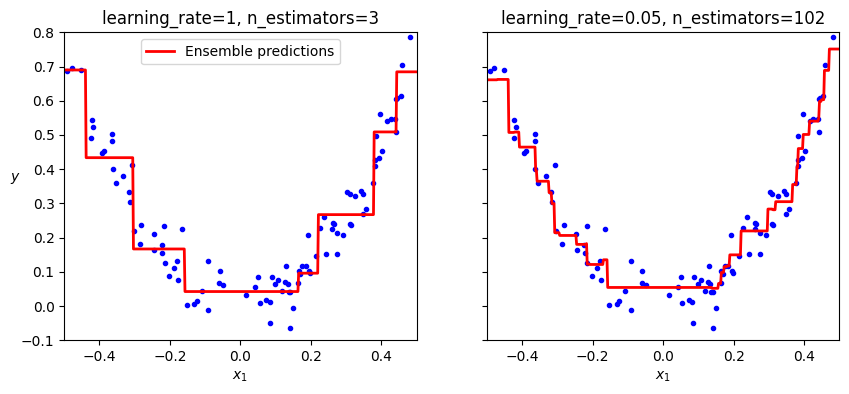

In [ ]:
import matplotlib.pyplot as plt

def plot_predictions(regressors, X, y, axes, style,
                     label=None, data_style="b.", data_label=None):
    x1 = np.linspace(axes[0], axes[1], 500)
    y_pred = sum(regressor.predict(x1.reshape(-1, 1))
                 for regressor in regressors)
    plt.plot(X[:, 0], y, data_style, label=data_label)
    plt.plot(x1, y_pred, style, linewidth=2, label=label)
    if label or data_label:
        plt.legend(loc="upper center")
    plt.axis(axes)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)

plt.sca(axes[0])
plot_predictions([gbrt], X, y, axes=[-0.5, 0.5, -0.1, 0.8], style="r-",
                 label="Ensemble predictions")
plt.title(f"learning_rate={gbrt.learning_rate}, "
          f"n_estimators={gbrt.n_estimators_}")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)

plt.sca(axes[1])
plot_predictions([gbrt_best], X, y, axes=[-0.5, 0.5, -0.1, 0.8], style="r-")
plt.title(f"learning_rate={gbrt_best.learning_rate}, "
          f"n_estimators={gbrt_best.n_estimators_}")
plt.xlabel("$x_1$")

plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import tarfile
import urllib.request
from pathlib import Path


def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)
housing_labels = train_set["median_house_value"]
housing = train_set.drop("median_house_value", axis=1)

/tmp/ipykernel_1744/2730745982.py:15: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tarball.extractall(path="datasets")


In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import OrdinalEncoder

hgb_reg = make_pipeline(
    make_column_transformer((OrdinalEncoder(), ["ocean_proximity"]),
                            remainder="passthrough"),
    HistGradientBoostingRegressor(categorical_features=[0], random_state=42)
)
hgb_reg.fit(housing, housing_labels)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinalencoder',
                                                  OrdinalEncoder(),
                                                  ['ocean_proximity'])])),
                ('histgradientboostingregressor',
                 HistGradientBoostingRegressor(categorical_features=[0],
                                               random_state=42))])

In [ ]:
from sklearn.model_selection import cross_val_score

hgb_rmses = -cross_val_score(hgb_reg, housing, housing_labels,
                             scoring="neg_root_mean_squared_error", cv=10)
pd.Series(hgb_rmses).describe()

,0
count,10.000000
mean,47613.307194
std,1295.422509
min,44963.213061
25%,47001.233485
50%,48000.963564
75%,48488.093243
max,49176.368465


# Stacking

In [ ]:
from sklearn.ensemble import StackingClassifier

In [ ]:
stacking_clf = StackingClassifier(
    estimators=[
        ('lr',LogisticRegression()),
        ('rf',RandomForestClassifier()),
        ('svc',SVC())
    ],
    final_estimator=RandomForestClassifier(random_state=43)
)

In [ ]:
stacking_clf.fit(X_train,y_train)

StackingClassifier(estimators=[('lr', LogisticRegression()),
                               ('rf', RandomForestClassifier()),
                               ('svc', SVC())],
                   final_estimator=RandomForestClassifier(random_state=43))

In [ ]:
stacking_clf.score(X_test,y_test)

0.928